In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:

# 1. Load the data
# Adjust path slightly since notebook is inside the 'notebooks' folder
df = pd.read_csv('../data/heart_disease_raw.csv')

In [3]:

# 2. Data Cleaning: Handle the target variable
# The UCI dataset often has target values from 0 to 4. 
# The assignment requires a binary target (0 = no disease, 1 = disease).
target_col = df.columns[-1] # Grabbing the last column (usually 'num' or 'target')
df['target'] = df[target_col].apply(lambda x: 1 if x > 0 else 0)
if target_col != 'target':
    df = df.drop(columns=[target_col])

# Check for missing values
print("Missing values per column:\n", df.isnull().sum())
# Fill missing values (if any) with the median for numerical columns
df = df.fillna(df.median())

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


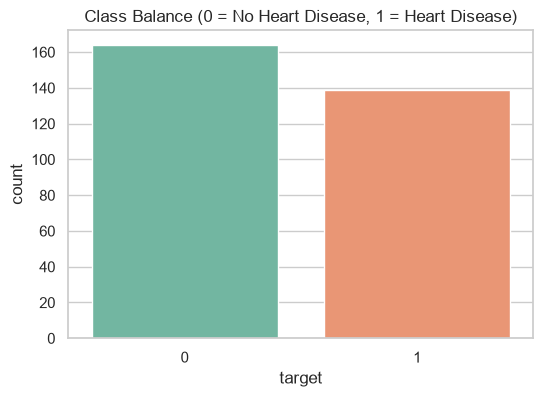

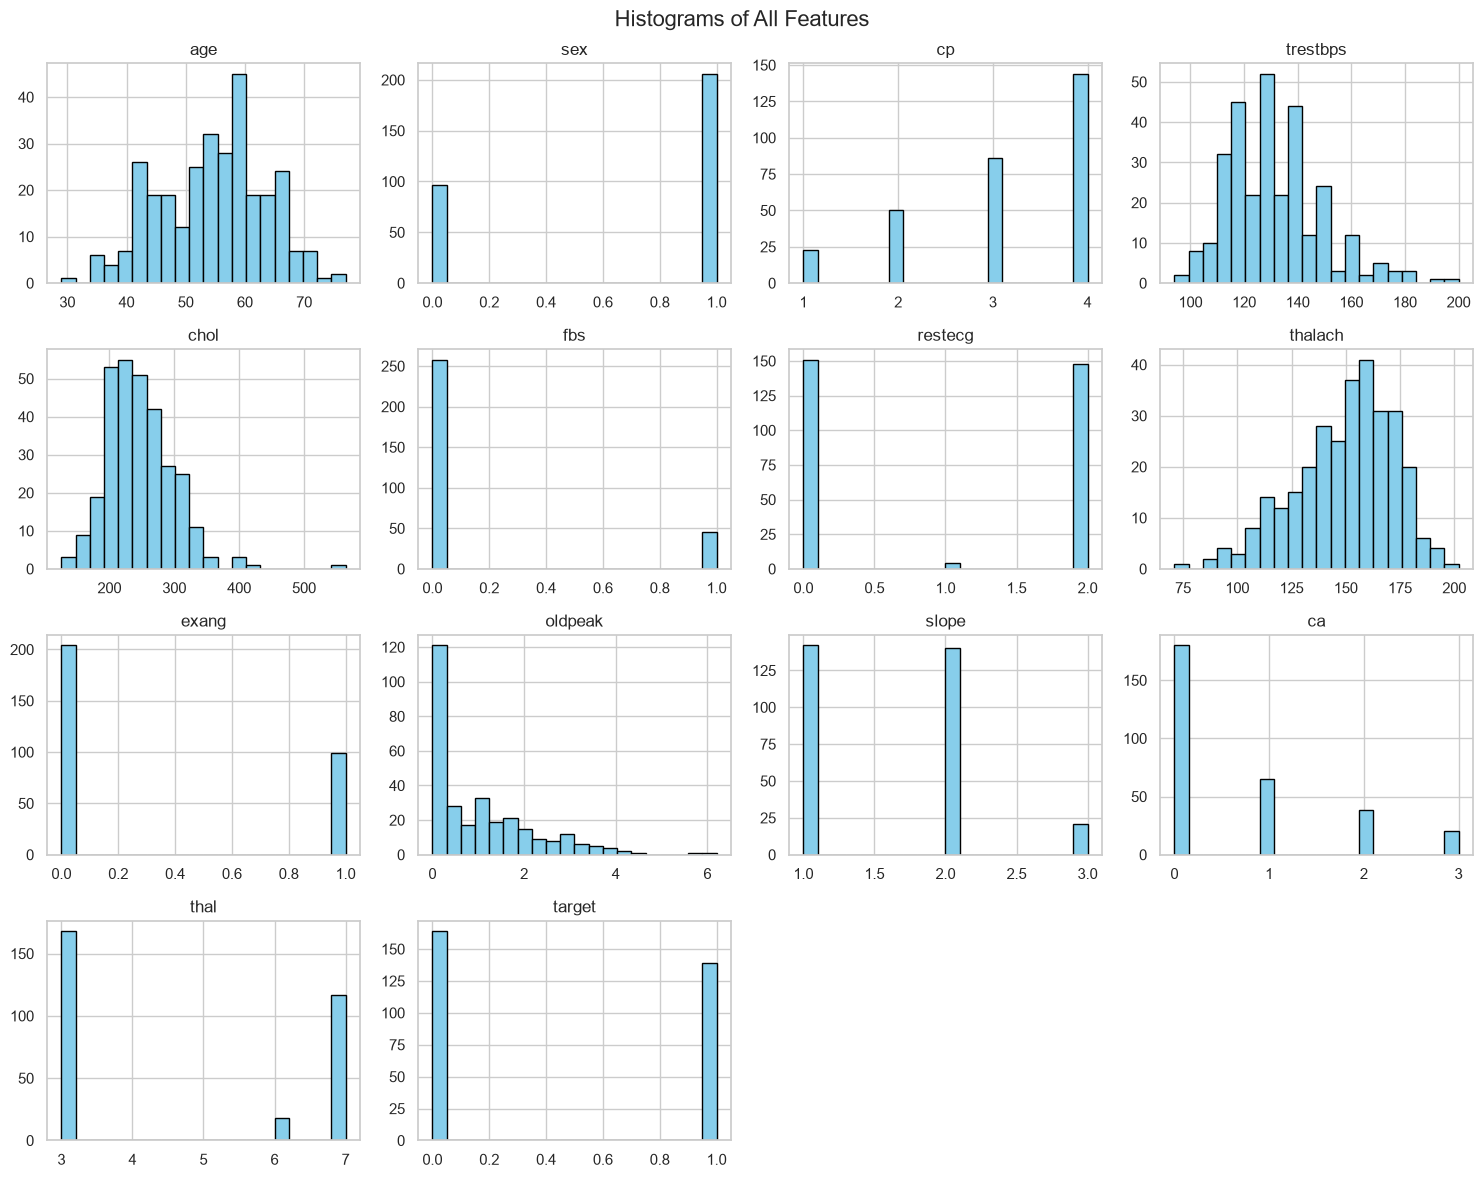

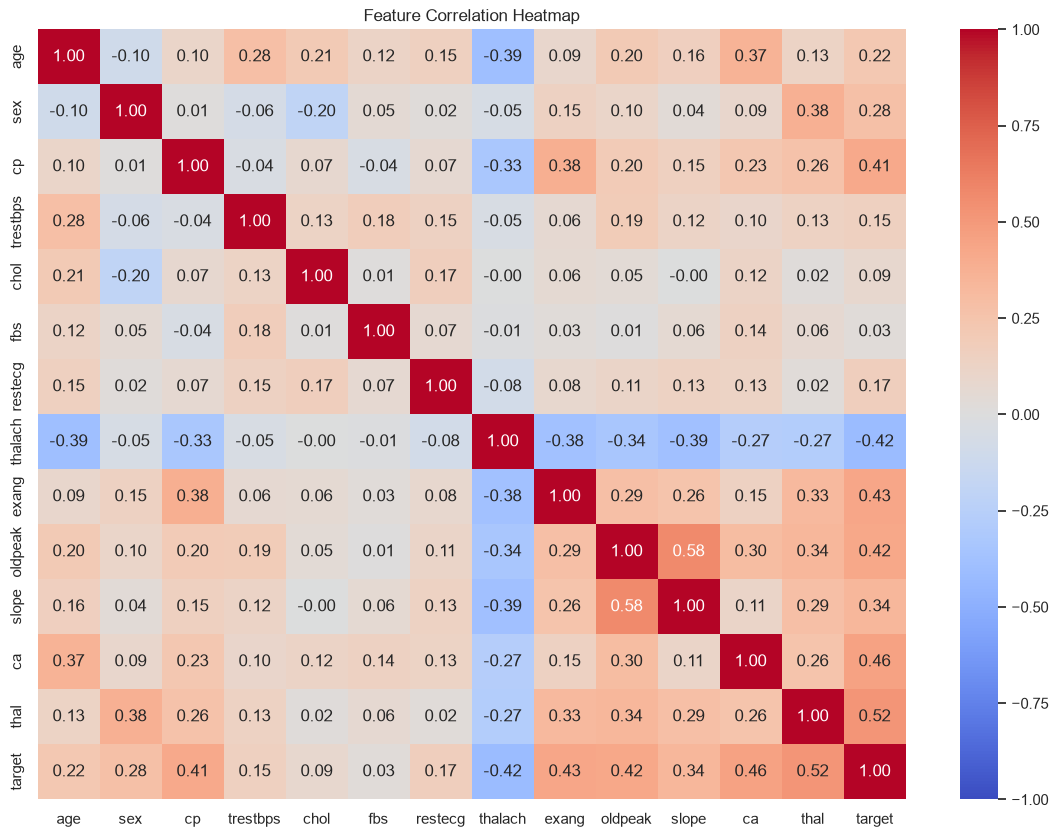

Cleaned data saved to 'data/heart_disease_cleaned.csv'


In [4]:
# 3. Exploratory Data Analysis (EDA)
sns.set_theme(style="whitegrid")

# Plot A: Class Balance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Class Balance (0 = No Heart Disease, 1 = Heart Disease)')
plt.show()

# Plot B: Histograms of Numerical Features
df.hist(figsize=(15, 12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of All Features', fontsize=16)
plt.tight_layout()
plt.show()

# Plot C: Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

# Save the cleaned dataset for model training
df.to_csv('../data/heart_disease_cleaned.csv', index=False)
print("Cleaned data saved to 'data/heart_disease_cleaned.csv'")